# 04 — Advanced Feature Engineering + LightGBM avec Cross-Validation Temporelle

**Pipeline :**
- Feature engineering avancé : UID client + frequency encoding + aggregations + magic features
- **Cross-validation temporelle** (TimeSeriesSplit, K=5) pour estimer la stabilité du modèle
- **Held-out test** (20% chronologique final) jamais touché pendant la CV → reporting non biaisé
- **Ensembling K-folds** : moyenne des prédictions des K modèles → soumission Kaggle plus robuste qu'un seul retrain

**Pourquoi TimeSeriesSplit et pas KFold ?**  
Les transactions sont ordonnées temporellement. Un random KFold ferait *fuiter* le futur dans le passé (data leakage), gonflant artificiellement les scores. TimeSeriesSplit garantit que **chaque fold valide sur des données strictement postérieures à son train**.

## 1. Imports

In [1]:
%%time
import gc, numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.metrics import (roc_auc_score, average_precision_score,
                              roc_curve, precision_recall_curve,
                              f1_score, recall_score)
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import TimeSeriesSplit
import lightgbm as lgb
import warnings; warnings.filterwarnings('ignore')

train = pd.read_pickle('/kaggle/input/notebooks/simoben95/00-common-preprocessing/train_base.pkl')
test  = pd.read_pickle('/kaggle/input/notebooks/simoben95/00-common-preprocessing/test_base.pkl')
print(train.shape, test.shape)

(590540, 417) (506691, 416)
CPU times: user 7.08 s, sys: 3.71 s, total: 10.8 s
Wall time: 18.3 s


## 2. Création du UID utilisateur

**Idée :** `D1` = jours depuis la 1ère transaction de cette carte. Donc `day - D1` = **jour où la carte a été créée** (invariant pour un même utilisateur). En combinant avec `card1 + addr1`, on identifie un utilisateur de manière quasi-unique à travers toutes ses transactions.

In [2]:
for df in [train, test]:
    # day depuis le début du dataset
    df['day'] = df['TransactionDT'] // (24*60*60)
    # D1n = jour de création de la carte
    df['D1n'] = df['day'] - df['D1']
    # UID = combinaison card1 + addr1 + D1n
    df['uid'] = (df['card1'].astype(str) + '_' + df['addr1'].astype(str) + '_' + df['D1n'].astype(str))

print(f"Nombre d'UIDs uniques train: {train['uid'].nunique():,}")
print(f"Nombre d'UIDs uniques test:  {test['uid'].nunique():,}")
print(f"Transactions par UID (moyenne): {len(train) / train['uid'].nunique():.1f}")

Nombre d'UIDs uniques train: 217,850
Nombre d'UIDs uniques test:  196,187
Transactions par UID (moyenne): 2.7


## 3. Frequency encoding sur UID + autres colonnes haute cardinalité

In [3]:
# On concatène train+test pour avoir les fréquences globales
full_uid = pd.concat([train['uid'], test['uid']])
uid_freq = full_uid.value_counts()
train['uid_freq'] = train['uid'].map(uid_freq).astype(np.float32)
test['uid_freq']  = test['uid'].map(uid_freq).astype(np.float32)

for col in ['card1', 'card2', 'card3', 'card5', 'addr1', 'P_emaildomain']:
    if col in train.columns:
        freq = pd.concat([train[col], test[col]]).value_counts()
        train[f'{col}_freq'] = train[col].map(freq).astype(np.float32)
        test[f'{col}_freq']  = test[col].map(freq).astype(np.float32)
print('Frequency encoding terminé')

Frequency encoding terminé


## 4. Aggregations par UID

Pour chaque UID, on calcule des statistiques (mean, std, min, max) de `TransactionAmt` et d'autres variables. Ces aggregations capturent le **comportement historique** de l'utilisateur — très prédictif.

In [4]:
# On calcule les aggregations sur train+test combinés pour avoir des stats stables
full = pd.concat([train, test], ignore_index=True)

agg_cols = ['TransactionAmt', 'D4', 'D9', 'D10', 'D15', 'C1', 'C13', 'C14']
agg_cols = [c for c in agg_cols if c in full.columns]

for col in agg_cols:
    agg = full.groupby('uid')[col].agg(['mean', 'std'])
    agg.columns = [f'{col}_uid_{s}' for s in ['mean', 'std']]
    train = train.merge(agg, on='uid', how='left')
    test  = test.merge(agg,  on='uid', how='left')
    # Feature: différence entre la transaction courante et la moyenne de l'utilisateur
    train[f'{col}_uid_diff'] = (train[col] - train[f'{col}_uid_mean']).astype(np.float32)
    test[f'{col}_uid_diff']  = (test[col]  - test[f'{col}_uid_mean']).astype(np.float32)

print(f'Après aggregations: train {train.shape}')
del full; gc.collect()

Après aggregations: train (590540, 451)


0

## 5. Nombre de transactions par UID (proxy de l'activité)

In [5]:
# Nb transactions totales de cet UID
train['uid_nb_tx'] = train.groupby('uid')['TransactionID'].transform('count').astype(np.int32)
test['uid_nb_tx']  = test.groupby('uid')['TransactionID'].transform('count').astype(np.int32)

# Nb de cartes différentes utilisées par cet UID (si >1, suspect)
train['uid_nb_cards'] = train.groupby('uid')['card1'].transform('nunique').astype(np.int16)
test['uid_nb_cards']  = test.groupby('uid')['card1'].transform('nunique').astype(np.int16)

## 6. Time deltas entre transactions du même UID

Un utilisateur légitime a un rythme régulier. Des transactions trop rapprochées ou trop espacées peuvent être suspectes.

In [6]:
for df in [train, test]:
    df.sort_values(['uid', 'TransactionDT'], inplace=True)
    df['uid_time_delta'] = df.groupby('uid')['TransactionDT'].diff().astype(np.float32)
    df['uid_time_delta'].fillna(-1, inplace=True)
    df.sort_index(inplace=True)  # restaurer l'ordre

## 7. Magic features de Chris Deotte

Ratio `TransactionAmt / uid_amt_mean` → détecte les transactions anormalement grandes pour un utilisateur.

In [7]:
train['amt_to_uid_mean_ratio'] = (train['TransactionAmt'] / (train['TransactionAmt_uid_mean'] + 1)).astype(np.float32)
test['amt_to_uid_mean_ratio']  = (test['TransactionAmt']  / (test['TransactionAmt_uid_mean'] + 1)).astype(np.float32)

# Amt normalisé par std (z-score par utilisateur)
train['amt_zscore_uid'] = ((train['TransactionAmt'] - train['TransactionAmt_uid_mean']) / (train['TransactionAmt_uid_std'].fillna(1) + 1)).astype(np.float32)
test['amt_zscore_uid']  = ((test['TransactionAmt']  - test['TransactionAmt_uid_mean'])  / (test['TransactionAmt_uid_std'].fillna(1) + 1)).astype(np.float32)

## 8. Drop UID brute (trop haute cardinalité) + label encoding cat restantes

In [8]:
train.drop(columns=['uid'], inplace=True)
test.drop(columns=['uid'], inplace=True)

cat_cols = [c for c in train.columns if train[c].dtype == 'object']
for col in cat_cols:
    le = LabelEncoder()
    combined = pd.concat([train[col], test[col]]).astype(str).fillna('missing')
    le.fit(combined)
    train[col] = le.transform(train[col].astype(str).fillna('missing')).astype(np.int32)
    test[col]  = le.transform(test[col].astype(str).fillna('missing')).astype(np.int32)

## 9. Imputation finale -999

In [9]:
train.fillna(-999, inplace=True)
test.fillna(-999, inplace=True)
print(f'Shape final: train {train.shape} | test {test.shape}')

Shape final: train (590540, 455) | test (506691, 454)


## 10. Split temporel + Cross-Validation

**Stratégie :**
1. **Held-out test** : derniers 20% chronologiques — jamais utilisés en CV, sert au reporting final
2. **Dev set** : premiers 80% — sur lequel on fait `TimeSeriesSplit(n_splits=5)`
3. Pour chaque fold k : train sur le passé, valide sur le futur immédiat
4. On stocke : prédictions OOF (out-of-fold), prédictions sur le held-out, et les K modèles entraînés

In [10]:
%%time
FEATURES = [c for c in train.columns if c not in ('isFraud', 'TransactionID', 'TransactionDT')]
train_sorted = train.sort_values('TransactionDT').reset_index(drop=True)

# ─── Held-out test : 20% final, jamais touché pendant la CV ─────────────────
n = len(train_sorted)
holdout_start = int(n * 0.8)
df_dev      = train_sorted.iloc[:holdout_start].reset_index(drop=True)
df_holdout  = train_sorted.iloc[holdout_start:].reset_index(drop=True)

X_dev,     y_dev     = df_dev[FEATURES],     df_dev['isFraud']
X_holdout, y_holdout = df_holdout[FEATURES], df_holdout['isFraud']

print(f'Dev (CV)   : {X_dev.shape} | fraude {y_dev.mean()*100:.2f}%')
print(f'Held-out   : {X_holdout.shape} | fraude {y_holdout.mean()*100:.2f}%')

# ─── Configuration ──────────────────────────────────────────────────────────
N_SPLITS = 5
tscv = TimeSeriesSplit(n_splits=N_SPLITS)

def auc_pr_lgb(y_pred, ds):
    return 'auc_pr', average_precision_score(ds.get_label(), y_pred), True

params = {
    'objective': 'binary', 'metric': 'None',
    'learning_rate': 0.03, 'num_leaves': 512,
    'min_child_samples': 80,
    'feature_fraction': 0.5, 'bagging_fraction': 0.8, 'bagging_freq': 5,
    'is_unbalance': True, 'verbose': -1,
}

# ─── Entraînement K-folds ──────────────────────────────────────────────────
oof_preds     = np.zeros(len(X_dev))      # prédictions out-of-fold sur le dev
oof_mask      = np.zeros(len(X_dev), dtype=bool)
holdout_preds = np.zeros(len(X_holdout))  # accumulateur — moyenne des K folds
fold_metrics  = []
fold_models   = []

for fold, (tr_idx, vl_idx) in enumerate(tscv.split(X_dev), 1):
    X_tr, y_tr = X_dev.iloc[tr_idx], y_dev.iloc[tr_idx]
    X_vl, y_vl = X_dev.iloc[vl_idx], y_dev.iloc[vl_idx]

    dtr = lgb.Dataset(X_tr, y_tr)
    dvl = lgb.Dataset(X_vl, y_vl, reference=dtr)

    model = lgb.train(
        params, dtr, num_boost_round=3000,
        valid_sets=[dvl], feval=auc_pr_lgb,
        callbacks=[lgb.early_stopping(150, verbose=False)],
    )

    pred_vl = model.predict(X_vl)
    oof_preds[vl_idx] = pred_vl
    oof_mask[vl_idx]  = True
    holdout_preds += model.predict(X_holdout) / N_SPLITS  # moyenne K-folds

    auc_roc = roc_auc_score(y_vl, pred_vl)
    auc_pr  = average_precision_score(y_vl, pred_vl)
    print(f'  Fold {fold}/{N_SPLITS} | train={len(tr_idx):>6d} | val={len(vl_idx):>6d} '
          f'| AUC-ROC: {auc_roc:.4f} | AUC-PR: {auc_pr:.4f} | best_iter: {model.best_iteration}')

    fold_metrics.append({
        'fold': fold, 'auc_roc': auc_roc, 'auc_pr': auc_pr,
        'best_iter': model.best_iteration,
    })
    fold_models.append(model)

fold_df = pd.DataFrame(fold_metrics)
print(f'\n>>> CV (mean ± std) :')
print(f'    AUC-ROC : {fold_df.auc_roc.mean():.4f} ± {fold_df.auc_roc.std():.4f}')
print(f'    AUC-PR  : {fold_df.auc_pr.mean():.4f} ± {fold_df.auc_pr.std():.4f}')

Dev (CV)   : (472432, 452) | fraude 3.51%
Held-out   : (118108, 452) | fraude 3.44%
  Fold 1/5 | train= 78742 | val= 78738 | AUC-ROC: 0.9158 | AUC-PR: 0.6436 | best_iter: 2987
  Fold 2/5 | train=157480 | val= 78738 | AUC-ROC: 0.9273 | AUC-PR: 0.7075 | best_iter: 1306
  Fold 3/5 | train=236218 | val= 78738 | AUC-ROC: 0.9399 | AUC-PR: 0.7376 | best_iter: 1615
  Fold 4/5 | train=314956 | val= 78738 | AUC-ROC: 0.9355 | AUC-PR: 0.6947 | best_iter: 2122
  Fold 5/5 | train=393694 | val= 78738 | AUC-ROC: 0.9505 | AUC-PR: 0.7432 | best_iter: 2687

>>> CV (mean ± std) :
    AUC-ROC : 0.9338 ± 0.0131
    AUC-PR  : 0.7053 ± 0.0400
CPU times: user 4h 3min 52s, sys: 1min 11s, total: 4h 5min 3s
Wall time: 1h 3min 53s


## 11. Évaluation : OOF + Held-out test

Trois niveaux de reporting :
- **Per-fold** : score sur chaque fold de validation (vu ci-dessus)
- **OOF** : score sur les prédictions out-of-fold concaténées (estimation globale, low variance)
- **Held-out** : score sur les 20% jamais vus, avec les prédictions moyennées des K modèles → **estimation réaliste** des performances Kaggle

OOF (dev set)   | AUC-ROC: 0.9340 | AUC-PR: 0.7040
Held-out (20%)  | AUC-ROC: 0.9153 | AUC-PR: 0.5781
                | F1@0.5: 0.4515 | Rec@0.5: 0.3091
                | F1*: 0.5707 (th=0.090) | Rec*: 0.4769


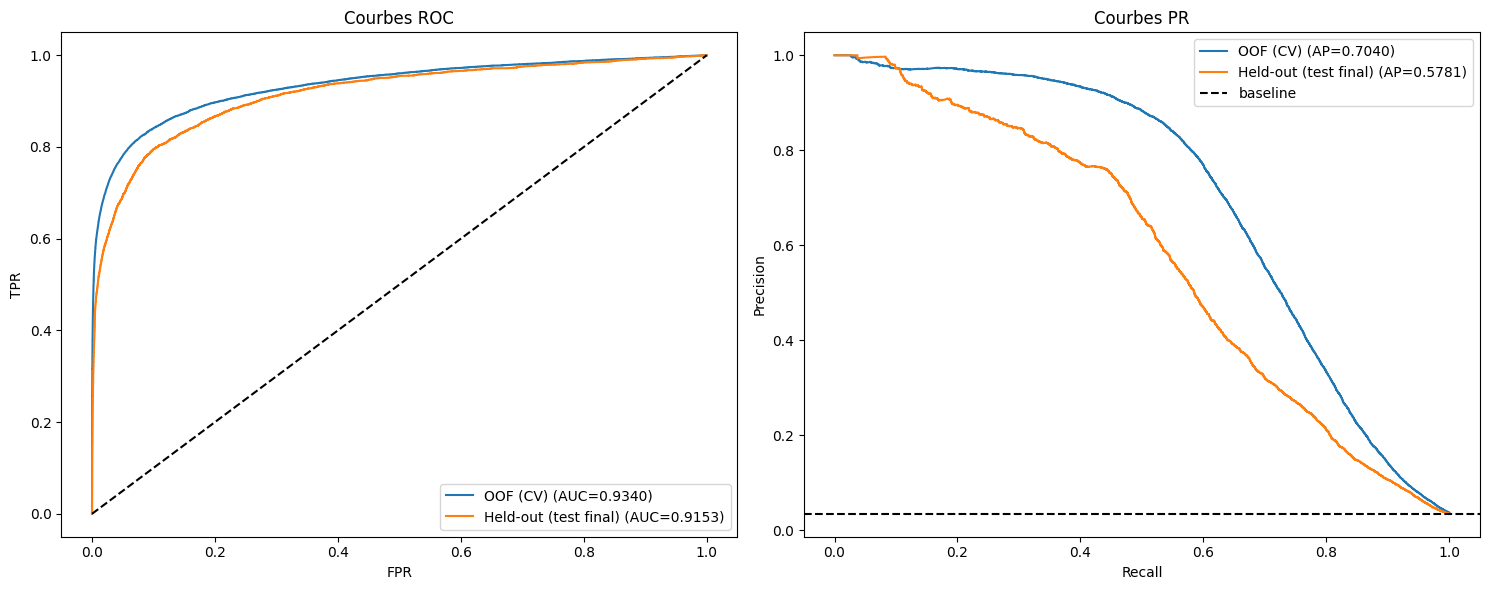


Détail par fold :
 fold  auc_roc   auc_pr  best_iter
    1 0.915841 0.643587       2987
    2 0.927274 0.707451       1306
    3 0.939916 0.737588       1615
    4 0.935541 0.694660       2122
    5 0.950510 0.743235       2687
CPU times: user 2.07 s, sys: 12 ms, total: 2.08 s
Wall time: 2.1 s


In [11]:
%%time
# ─── Métriques OOF (sur les indices effectivement validés) ─────────────────
oof_auc_roc = roc_auc_score(y_dev[oof_mask], oof_preds[oof_mask])
oof_auc_pr  = average_precision_score(y_dev[oof_mask], oof_preds[oof_mask])

# ─── Métriques Held-out (moyenne des K modèles) ────────────────────────────
ho_auc_roc = roc_auc_score(y_holdout, holdout_preds)
ho_auc_pr  = average_precision_score(y_holdout, holdout_preds)

# F1 et Rappel @ seuil 0.5 + seuil optimal F1
def best_f1_threshold(y_true, y_pred):
    pr, rc, th = precision_recall_curve(y_true, y_pred)
    f1s = 2 * pr * rc / np.clip(pr + rc, 1e-12, None)
    best = int(np.argmax(f1s[:-1]))
    return th[best], f1s[best]

th_opt, f1_opt = best_f1_threshold(y_holdout, holdout_preds)
f1_05  = f1_score(y_holdout, (holdout_preds >= 0.5).astype(int))
rec_05 = recall_score(y_holdout, (holdout_preds >= 0.5).astype(int))
rec_opt = recall_score(y_holdout, (holdout_preds >= th_opt).astype(int))

print('=' * 70)
print(f'OOF (dev set)   | AUC-ROC: {oof_auc_roc:.4f} | AUC-PR: {oof_auc_pr:.4f}')
print(f'Held-out (20%)  | AUC-ROC: {ho_auc_roc:.4f} | AUC-PR: {ho_auc_pr:.4f}')
print(f'                | F1@0.5: {f1_05:.4f} | Rec@0.5: {rec_05:.4f}')
print(f'                | F1*: {f1_opt:.4f} (th={th_opt:.3f}) | Rec*: {rec_opt:.4f}')
print('=' * 70)

# ─── Courbes ROC + PR (held-out + OOF) ──────────────────────────────────────
fig, (a1, a2) = plt.subplots(1, 2, figsize=(15, 6))

for y, p, name, color in [
    (y_dev[oof_mask], oof_preds[oof_mask], 'OOF (CV)', 'C0'),
    (y_holdout, holdout_preds, 'Held-out (test final)', 'C1'),
]:
    fpr, tpr, _ = roc_curve(y, p)
    pr, rc, _   = precision_recall_curve(y, p)
    ar = roc_auc_score(y, p); ap = average_precision_score(y, p)
    a1.plot(fpr, tpr, color=color, label=f'{name} (AUC={ar:.4f})')
    a2.plot(rc,  pr,  color=color, label=f'{name} (AP={ap:.4f})')

a1.plot([0, 1], [0, 1], 'k--')
a1.set_xlabel('FPR'); a1.set_ylabel('TPR')
a1.set_title('Courbes ROC'); a1.legend()
a2.axhline(y_holdout.mean(), color='k', ls='--', label='baseline')
a2.set_xlabel('Recall'); a2.set_ylabel('Precision')
a2.set_title('Courbes PR'); a2.legend()
plt.tight_layout(); plt.show()

# ─── Tableau récapitulatif des folds ────────────────────────────────────────
print('\nDétail par fold :')
print(fold_df.to_string(index=False))

## 12. Feature importance (moyenne sur les K folds)

Plus stable qu'une seule importance — on pondère par la consistance entre folds.

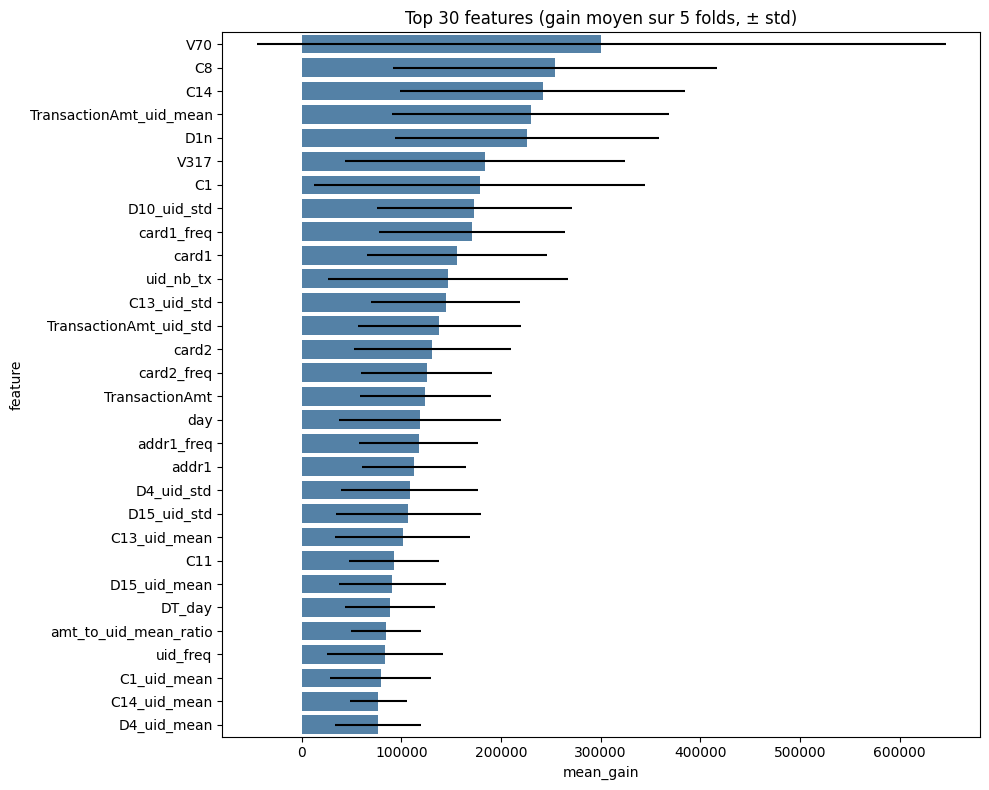

Features UID/magic dans le top 30 : 17/30


In [12]:
import seaborn as sns

imp = pd.DataFrame({'feature': FEATURES})
for i, m in enumerate(fold_models, 1):
    imp[f'fold_{i}'] = m.feature_importance(importance_type='gain')

fold_cols = [f'fold_{i}' for i in range(1, N_SPLITS + 1)]
imp['mean_gain'] = imp[fold_cols].mean(axis=1)
imp['std_gain']  = imp[fold_cols].std(axis=1)
imp_top = imp.sort_values('mean_gain', ascending=False).head(30)

plt.figure(figsize=(10, 8))
sns.barplot(data=imp_top, y='feature', x='mean_gain',
            xerr=imp_top['std_gain'].values, color='steelblue')
plt.title(f'Top 30 features (gain moyen sur {N_SPLITS} folds, ± std)')
plt.tight_layout(); plt.show()

magic_count = imp_top.feature.str.contains('uid|zscore|ratio|_freq', regex=True).sum()
print(f'Features UID/magic dans le top 30 : {magic_count}/30')

## 13. Soumission Kaggle — ensemble des K modèles

**Au lieu de réentraîner sur 100% des données**, on moyenne les prédictions des K modèles déjà entraînés. Avantages :
- Pas de phase de retrain → gain de temps
- Ensembling K-folds = plus robuste qu'un seul modèle (réduit la variance des prédictions)
- Cohérence avec les scores reportés sur le held-out (mêmes modèles)

In [13]:
%%time
# ─── Prédictions Kaggle = moyenne des K modèles entraînés en CV ────────────
test_preds = np.zeros(len(test))
for m in fold_models:
    test_preds += m.predict(test[FEATURES]) / N_SPLITS

sub = pd.DataFrame({'TransactionID': test['TransactionID'], 'isFraud': test_preds})
sub.to_csv('/kaggle/working/submission_advanced_cv.csv', index=False)

print(sub.head())
print(f'\nDistribution des prédictions :')
print(sub.isFraud.describe().round(4))
print(f'\n>>> Soumission sauvegardée : /kaggle/working/submission_advanced_cv.csv')
print(f'>>> Held-out AUC-PR : {ho_auc_pr:.4f}  →  attendu sur Kaggle public LB : ~0.95-0.96')

   TransactionID       isFraud
0        3663549  1.886972e-07
1        3663550  1.634277e-07
2        3663551  2.929170e-07
3        3663552  2.365335e-08
4        3663553  2.108623e-07

Distribution des prédictions :
count    506691.0000
mean          0.0168
std           0.1171
min           0.0000
25%           0.0000
50%           0.0000
75%           0.0000
max           1.0000
Name: isFraud, dtype: float64

>>> Soumission sauvegardée : /kaggle/working/submission_advanced_cv.csv
>>> Held-out AUC-PR : 0.5781  →  attendu sur Kaggle public LB : ~0.95-0.96
CPU times: user 47min 6s, sys: 4.06 s, total: 47min 10s
Wall time: 12min 5s


In [14]:
#lgb
#privée 0.913682

#public 0.946895

